# CLERO quickstart

Predict a planet's climate and have a look

In [1]:
%matplotlib inline
import numpy as np

from clero import Emulator
from clero.climate_analysis import latitude_centers, field_map, plot_profile

## Inputs

In [2]:
INPUTS = {
    "T_star": 3000.0,     # K
    "F_star": 1500.0,     # W/m^2
    "radius": 1.0,        # Earth radii
    "gravity": 10.0,       # m/s^2
    "P_rot": 10.0,        # days
    "P0": 1.0,            # bar
    "CO2": 0.0,        # volume fraction
    "CH4": 0.0,           # volume fraction
    "GCM": "um",          # target GCM (optional; defaults to "um")
}

emu = Emulator()

## Predict and plot

`predict` returns one 32×64 field per output, keyed by name. `field_map` is a quick look at any 2D field; `plot_profile` shows the vertical global-mean profile for a 3D variable.

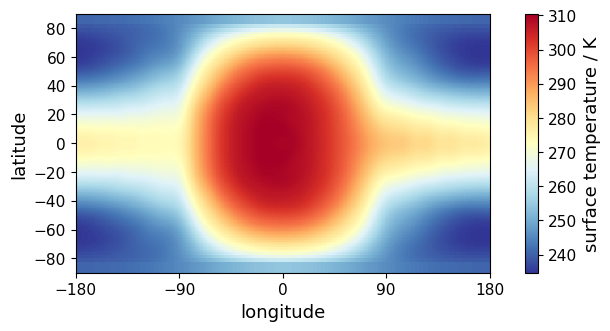

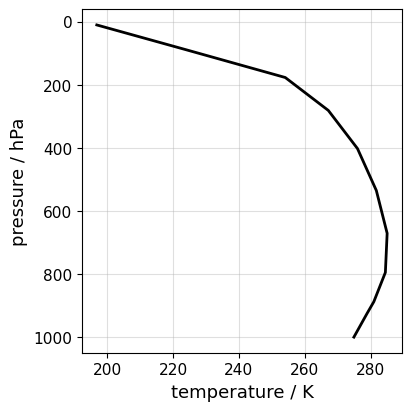

In [3]:
climate = emu.predict(INPUTS) # the mean of CLERO's climate distribution 
lat = latitude_centers(climate["surface_temperature"].shape[0])

fig, ax = field_map(climate, "surface_temperature", lat=lat, units="surface temperature / K")
fig, ax = plot_profile(climate, "temperature", lat=lat, P0=INPUTS["P0"], units="temperature / K", log_yscale=False)

## Variance

`return_variance=True` gives the variance of each field at every grid cell. It should be computed in model space, at least initially; for surface temperature that is the same as physical units, while for humidity and cloud fraction it means log or logit units (see `uncertainty.ipynb`).

In [4]:
mean_m, var_m = emu.predict(INPUTS, space="model", return_variance=True, fields=["surface_temperature"])
std = np.sqrt(var_m["surface_temperature"])
print(f"per-cell std of surface T: {std.min():.1f} to {std.max():.1f} K")

per-cell std of surface T: 5.6 to 13.1 K


## Samples

`sample` draws climates from CLERO's climate distribution. 

`fields=[...]` restricts the computation and the output to the named fields. This matters for memory when drawing many samples -- 256 samples of all 53 fields is 256 × 53 maps of 32 × 64 values, which can quickly add up to a lot in a big batch of planets!

In [5]:
samples = emu.sample(INPUTS, n_samples=256, seed=0, fields=["surface_temperature", "asr"])
samples["asr"].shape

(256, 32, 64)

## Where next

- `trappist1e.ipynb`: a single-planet report with maps, area means, vertical profiles and CSV export.
- `uncertainty.ipynb`: uncertainties from samples and the analytic variance, summarizing humidity, and how uncertainty grows outside the core domain.
- `mosaic_of_diagnostics.ipynb`: a demo of batch prediction on CPU or GPU.